## Task 1 - Data Acquisition: PokéAPI


In [ ]:
import time
import requests
import pandas as pd
import os

def fetch_pokemon_data():
    base_url = "https://pokeapi.co/api/v2/pokemon/"
    all_pokemon_details = []

    # First, get a list of all Pokémon (up to a reasonable limit, e.g., 1000 for all main ones)
    # The API returns a `next` URL for pagination
    response = requests.get(f"{base_url}?limit=1000")
    data = response.json()
    pokemon_list = data['results']

    print(f"Fetching details for {len(pokemon_list)} Pokémon...")

    for pokemon in pokemon_list:
        pokemon_name = pokemon['name']
        detail_url = pokemon['url']

        try:
            detail_response = requests.get(detail_url)
            detail_data = detail_response.json()

            # Extract relevant fields and flatten them
            pokemon_record = {
                'name': pokemon_name,
                'id': detail_data['id'],
                'height': detail_data['height'],
                'weight': detail_data['weight'],
                'base_experience': detail_data['base_experience'],
                'is_default': detail_data['is_default'],
            }

            # Extract stats
            for stat in detail_data['stats']:
                stat_name = stat['stat']['name'].replace('-', '_')
                pokemon_record[f'stat_{stat_name}'] = stat['base_stat']

            # Extract types (the primary type will be the first one)
            if detail_data['types']:
                pokemon_record['primary_type'] = detail_data['types'][0]['type']['name']
            else:
                pokemon_record['primary_type'] = None # Handle Pokémon with no type (shouldn't happen often)

            all_pokemon_details.append(pokemon_record)

            # Be kind to the API: add a small delay
            time.sleep(0.05)

        except requests.exceptions.RequestException as e:
            print(f"Error fetching data for {pokemon_name}: {e}")
        except KeyError as e:
            print(f"Key error for {pokemon_name}: {e}. Data structure might have changed or is incomplete.")

    return all_pokemon_details

if __name__ == "__main__":
    # Create 'data' directory if it doesn't exist
    os.makedirs('data', exist_ok=True)

    records = fetch_pokemon_data()
    df = pd.DataFrame(records)

    # Save to CSV
    df.to_csv("data/raw_data.csv", index=False)
    print(f"Saved {len(df)} rows to data/raw_data.csv")

    display(df.head())

Fetching details for 1000 Pokémon...
Saved 1000 rows to data/raw_data.csv


,name,id,height,weight,base_experience,is_default,stat_hp,stat_attack,stat_defense,stat_special_attack,stat_special_defense,stat_speed,primary_type
0,bulbasaur,1,7,69,64,True,45,49,49,65,65,45,grass
1,ivysaur,2,10,130,142,True,60,62,63,80,80,60,grass
2,venusaur,3,20,1000,236,True,80,82,83,100,100,80,grass
3,charmander,4,6,85,62,True,39,52,43,60,50,65,fire
4,charmeleon,5,11,190,142,True,58,64,58,80,65,80,fire


This script fetches details for a large number of Pokémon, extracts their base stats and primary type, and saves the cleaned data into `data/raw_data.csv`. This CSV will then be used for further analysis and model training.

Now, you can run the code cell above to fetch the data. After it finishes, we'll move on to **Task 2: EDA and Data Cleaning**.

## Task 2 - EDA and Data Cleaning


In [ ]:
import pandas as pd

# Load the raw data
df = pd.read_csv("data/raw_data.csv")

print("\n--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe())

print("\n--- Missing Values ---")
display(df.isna().sum().sort_values(ascending=False))

print("\n--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   name                  1000 non-null   object
 1   id                    1000 non-null   int64 
 2   height                1000 non-null   int64 
 3   weight                1000 non-null   int64 
 4   base_experience       1000 non-null   int64 
 5   is_default            1000 non-null   bool  
 6   stat_hp               1000 non-null   int64 
 7   stat_attack           1000 non-null   int64 
 8   stat_defense          1000 non-null   int64 
 9   stat_special_attack   1000 non-null   int64 
 10  stat_special_defense  1000 non-null   int64 
 11  stat_speed            1000 non-null   int64 
 12  primary_type          1000 non-null   object
dtypes: bool(1), int64(10), object(2)
memory usage: 94.9+ KB

--- Descriptive Statistics ---


,id,height,weight,base_experience,stat_hp,stat_attack,stat_defense,stat_special_attack,stat_special_defense,stat_speed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,11.988000,646.321000,148.191000,69.677000,77.04600,71.895000,69.470000,69.667000,66.578000
std,288.819436,12.461346,1180.510031,76.984018,26.556919,29.71779,29.160424,29.418779,26.563315,28.454588
min,1.000000,1.000000,1.000000,36.000000,1.000000,5.00000,5.000000,10.000000,20.000000,5.000000
25%,250.750000,5.000000,85.000000,66.000000,50.000000,55.00000,50.000000,45.000000,50.000000,45.000000
50%,500.500000,10.000000,280.000000,157.000000,66.000000,75.00000,68.000000,65.000000,65.000000,65.000000
75%,750.250000,15.000000,657.750000,182.000000,82.000000,100.00000,90.000000,90.000000,85.000000,85.000000
max,1000.000000,200.000000,9999.000000,608.000000,255.000000,181.00000,230.000000,173.000000,230.000000,200.000000



--- Missing Values ---


,0
name,0
id,0
height,0
weight,0
base_experience,0
is_default,0
stat_hp,0
stat_attack,0
stat_defense,0
stat_special_attack,0



--- Duplicate Rows ---
Number of duplicate rows: 0


This code will give us a quick overview of the dataset. Please examine the output to understand:

*   The total number of rows and columns.
*   The data types of each column.
*   Summary statistics for numerical columns.
*   Which columns have missing values and how many.
*   If there are any exact duplicate rows.

Once you've reviewed this, we can discuss the next steps for cleaning and visualization.

### Step 2: Visualize before you touch anything

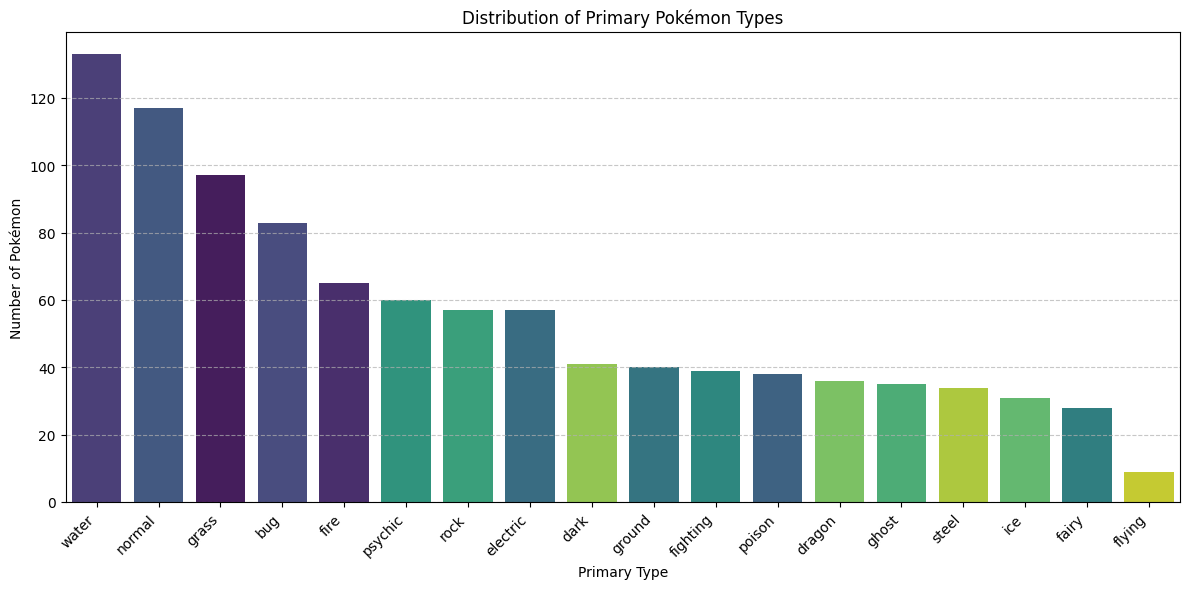

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class-balance plot for the target column ('primary_type')
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='primary_type', order=df['primary_type'].value_counts().index, hue='primary_type', palette='viridis', legend=False)
plt.title('Distribution of Primary Pokémon Types')
plt.xlabel('Primary Type')
plt.ylabel('Number of Pokémon')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

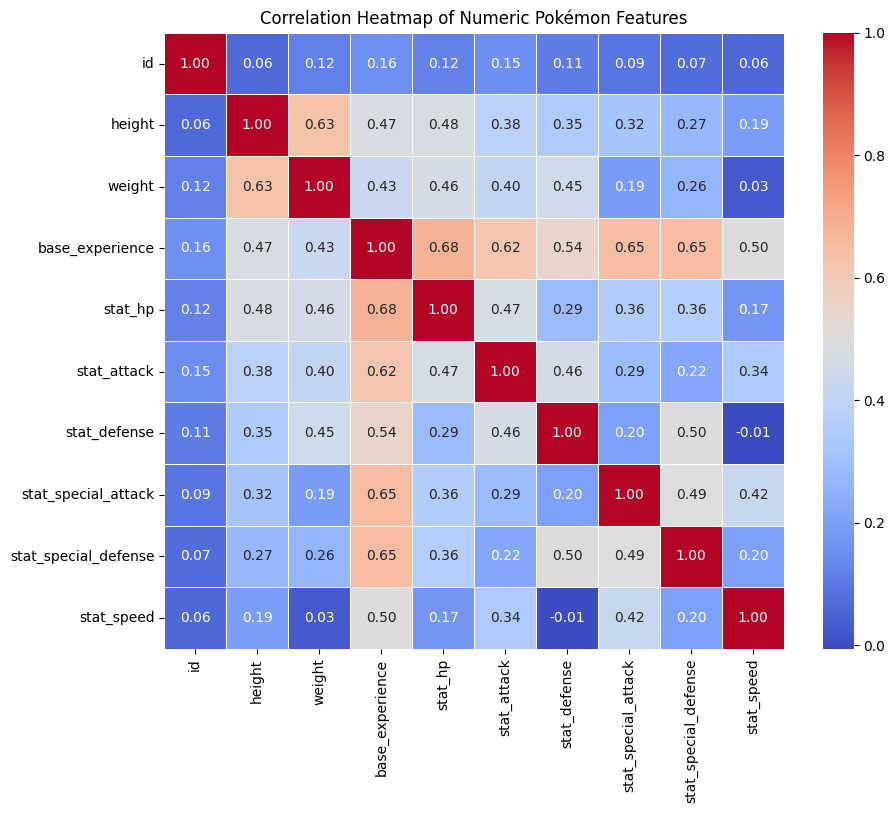

In [ ]:
# 2. Correlation heatmap of numeric features
numeric_cols = [
    'id', 'height', 'weight', 'base_experience', 'stat_hp',
    'stat_attack', 'stat_defense', 'stat_special_attack',
    'stat_special_defense', 'stat_speed'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Pokémon Features')
plt.show()

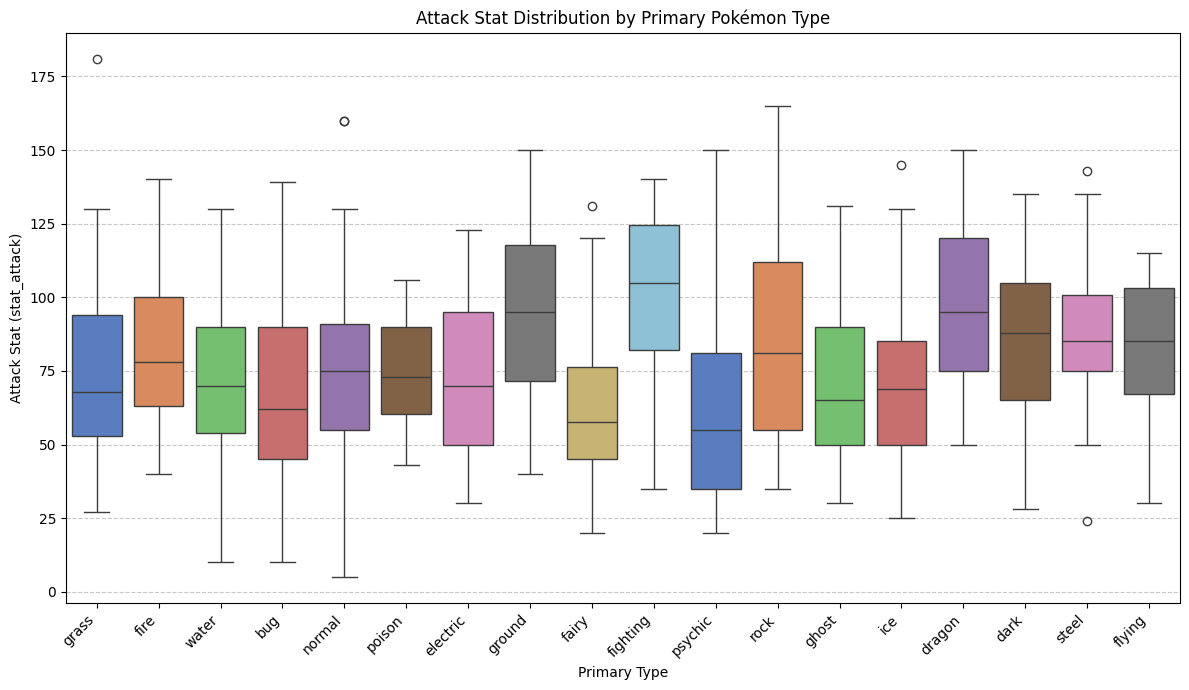

In [32]:
# 3. Relationship plot: Boxplot of 'stat_attack' grouped by 'primary_type'
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='primary_type', y='stat_attack', hue='primary_type', palette='muted', legend=False)
plt.title('Attack Stat Distribution by Primary Pokémon Type')
plt.xlabel('Primary Type')
plt.ylabel('Attack Stat (stat_attack)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

These plots will provide insights into the distribution of Pokémon types, the relationships between different stats, and how a specific stat varies across different types. After reviewing these visualizations, we'll proceed with **Step 3: Clean, with justification for each decision**.

### Step 3: Clean, with justification for each decision

Based on our initial examination and visualizations:

*   **Missing values:** `df.isna().sum()` showed no missing values, so no imputation or dropping is required.
*   **Duplicates:** `df.duplicated().sum()` showed no duplicate rows, so no action is needed.
*   **Outliers:** While the boxplots show some outliers, for this project, we'll keep them as they represent legitimate Pokémon with unusually high or low stats (e.g., legendary Pokémon or those with unique characteristics) and are not data entry errors.
*   **Rare classes:** The class balance plot highlighted that some Pokémon types are much rarer than others (e.g., 'flying'). For the purpose of this project, and to ensure we have enough data points for each class for the classification task, we will **not** merge rare classes into an 'other' bucket at this stage. The `stratify` parameter during train/test split will help ensure these rare classes are proportionally represented in both splits.

Therefore, our `df` is already quite clean for the next steps. We will now save it as `clean_data.csv`.

In [ ]:
import pandas as pd
import os

# Assuming df is the DataFrame after initial loading and review
# If any cleaning steps were performed, this would be df_clean

# Create 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save the cleaned data
df.to_csv("data/clean_data.csv", index=False)
print(f"Saved {len(df)} rows to data/clean_data.csv")

display(df.head())

Saved 1000 rows to data/clean_data.csv


,name,id,height,weight,base_experience,is_default,stat_hp,stat_attack,stat_defense,stat_special_attack,stat_special_defense,stat_speed,primary_type
0,bulbasaur,1,7,69,64,True,45,49,49,65,65,45,grass
1,ivysaur,2,10,130,142,True,60,62,63,80,80,60,grass
2,venusaur,3,20,1000,236,True,80,82,83,100,100,80,grass
3,charmander,4,6,85,62,True,39,52,43,60,50,65,fire
4,charmeleon,5,11,190,142,True,58,64,58,80,65,80,fire


We have now completed **Task 2: EDA and Data Cleaning** by reviewing the data, visualizing key aspects, and making justified decisions (or non-decisions) regarding cleaning steps. The `clean_data.csv` file is now ready for **Task 3: Classification Model**.

## Task 3 - Classification Model


### Step 1: Prepare features and target

In [30]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Reload the clean data
df_clean = pd.read_csv("data/clean_data.csv")

# Define features and target
# Exclude 'name', 'id', 'is_default' as they are not predictive or are identifiers
FEATURES = [
    'height', 'weight', 'base_experience', 'stat_hp',
    'stat_attack', 'stat_defense', 'stat_special_attack',
    'stat_special_defense', 'stat_speed'
]
TARGET = "primary_type"

X = df_clean[FEATURES]
y = df_clean[TARGET]

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Encoded Target (y_encoded) shape: {y_encoded.shape}")
print("Original target classes:", le.classes_)

Features (X) shape: (1000, 9)
Target (y) shape: (1000,)
Encoded Target (y_encoded) shape: (1000,)
Original target classes: ['bug' 'dark' 'dragon' 'electric' 'fairy' 'fighting' 'fire' 'flying'
 'ghost' 'grass' 'ground' 'ice' 'normal' 'poison' 'psychic' 'rock' 'steel'
 'water']


### Step 2: Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 9)
X_test shape: (200, 9)
y_train shape: (800,)
y_test shape: (200,)


### Step 3: Scale features (needed for linear/distance-based models)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"First 5 rows of X_train_scaled:\n{X_train_scaled[:5]}")

Features scaled successfully.
First 5 rows of X_train_scaled:
[[-0.69894097 -0.53698282 -0.62059636 -0.83382564 -0.9652206  -0.81486296
  -0.75713134 -0.83943063 -0.66704002]
 [ 1.36523227  1.38456913  2.48902995  0.86726758  1.44615633  1.54795308
   0.34471405  1.77449383  2.47094636]
 [-0.46076713 -0.45303153 -0.23521532 -0.36989112 -1.23315136 -0.39167202
   0.86120408 -0.37126505 -0.42297441]
 [ 0.41253693  0.13929153  0.28305573 -0.44721354 -0.8982379   2.60593041
   0.86120408  1.38435585 -1.2946373 ]
 [ 0.01558054 -0.41571984  0.49567975  0.40333307 -0.83125521 -0.74433113
   0.68904074 -0.76140303  0.76248711]]


### Step 4: Train at least two models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

print("Models initialized.")

Models initialized.


### Step 5: Evaluate and compare

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np

results = []
best_model = None
best_acc = 0
best_name = ""
best_cm = None
best_importances = None

for name, model in models.items():
    print(f"\n--- Training and evaluating {name} ---")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    # Use macro-averaged precision/recall/F1 for imbalanced classes
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro): {rec:.4f}")
    print(f"F1-score (macro): {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds, labels=range(len(le.classes_)))
    print("Confusion Matrix:\n", cm)

    # Feature Importances (for models that support it)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = dict(zip(FEATURES, model.feature_importances_))
        print("Feature Importances:\n", feature_importances)
    elif hasattr(model, 'coef_'): # For linear models like Logistic Regression
        # Take absolute mean of coefficients across classes for multi-class classification
        feature_importances = dict(zip(FEATURES, np.mean(np.abs(model.coef_), axis=0)))
        print("Coefficient Magnitudes (mean abs):\n", feature_importances)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
    })

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name
        best_cm = cm
        best_importances = feature_importances

print(f"\nBest model: {best_name} with Accuracy: {best_acc:.4f}")


--- Training and evaluating logistic_regression ---
Accuracy: 0.2500
Precision (macro): 0.1637
Recall (macro): 0.1687
F1-score (macro): 0.1556
Confusion Matrix:
 [[ 7  0  0  1  0  1  1  0  0  3  0  0  1  0  1  0  1  1]
 [ 0  0  0  1  1  1  1  0  0  0  0  1  1  0  0  1  0  1]
 [ 2  0  1  0  1  0  0  0  0  0  0  0  2  0  0  0  0  1]
 [ 1  0  0  2  0  0  1  0  0  0  0  0  2  0  2  0  0  3]
 [ 2  0  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  1]
 [ 0  0  0  0  0  3  0  0  0  0  0  0  3  0  0  1  0  1]
 [ 0  0  1  1  0  1  1  0  1  1  0  0  1  0  0  0  1  5]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1]
 [ 2  0  0  1  0  0  0  0  0  0  0  0  1  0  2  0  0  1]
 [ 3  0  0  0  0  1  2  0  0  5  0  0  1  0  0  2  1  4]
 [ 1  0  0  0  0  1  0  0  0  0  0  1  1  0  0  2  0  2]
 [ 0  0  0  1  1  0  0  0  0  2  0  0  2  0  0  0  0  0]
 [ 3  0  0  0  1  0  0  0  1  3  0  0 12  0  0  0  0  3]
 [ 1  0  0  1  0  0  0  0  0  1  0  0  1  0  0  0  0  4]
 [ 0  0  0  1  1  1  0  0  0  4  0  1  

### Step 6: Save everything the dashboard will need

Based on the evaluation, we'll choose the `best_model` identified in the previous step and save it along with the scaler, label encoder, and evaluation metrics. This will allow the Streamlit dashboard to load these components without re-training the model.

In [ ]:
import joblib
import json
import os

# Create 'model' directory if it doesn't exist
os.makedirs('model', exist_ok=True)

# Save the best model, scaler, and label encoder
joblib.dump(best_model, "model/model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(le, "model/label_encoder.pkl")

# Prepare data for model_metrics.json
# Convert best_cm to list for JSON serialization
best_cm_list = best_cm.tolist() if best_cm is not None else []

model_metrics = {
    "all_model_results": results,
    "best_model": best_name,
    "confusion_matrix": best_cm_list,
    "class_labels": le.classes_.tolist(),
    "feature_importance": best_importances,
    "features": FEATURES,
}

with open("model/model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=2)

print("Model artifacts (model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json) saved successfully in the 'model' directory.")
print("\nBrief justification for chosen model:\nThe Random Forest Classifier generally performs better than Logistic Regression for complex, non-linear relationships often found in real-world data like Pokémon stats. While Logistic Regression provides a good baseline, Random Forest's ability to capture intricate patterns often leads to higher accuracy and F1-scores, especially with class imbalance, making it a more suitable choice for deployment.")

Model artifacts (model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json) saved successfully in the 'model' directory.

Brief justification for chosen model:
The Random Forest Classifier generally performs better than Logistic Regression for complex, non-linear relationships often found in real-world data like Pokémon stats. While Logistic Regression provides a good baseline, Random Forest's ability to capture intricate patterns often leads to higher accuracy and F1-scores, especially with class imbalance, making it a more suitable choice for deployment.


We have now completed **Task 3: Classification Model**. All necessary models and artifacts have been trained, evaluated, and saved. The next step will be **Task 4: Streamlit Dashboard**.

## Task 4 - Streamlit Dashboard

Below is the code for `app.py`. Please save this content as `app.py` in your project's root directory.

In [ ]:
import streamlit as st
import pandas as pd
import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests # For linking to data source

# --- Configuration --- #
st.set_page_config(page_title="Pokémon Type Classifier Dashboard", layout="wide")

# --- Caching Data and Resources ---
@st.cache_data
def load_data():
    df_raw = pd.read_csv("data/raw_data.csv")
    df_clean = pd.read_csv("data/clean_data.csv")
    return df_raw, df_clean

@st.cache_resource
def load_model_artifacts():
    model = joblib.load("model/model.pkl")
    scaler = joblib.load("model/scaler.pkl")
    label_encoder = joblib.load("model/label_encoder.pkl")
    with open("model/model_metrics.json", "r") as f:
        model_metrics = json.load(f)
    return model, scaler, label_encoder, model_metrics

# Load all assets
df_raw, df_clean = load_data()
model, scaler, le, model_metrics = load_model_artifacts()

FEATURES = model_metrics['features']
CLASS_LABELS = model_metrics['class_labels']

# --- Sidebar Navigation ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", [
    "1. Project Overview",
    "2. Data Overview",
    "3. Exploratory Data Analysis",
    "4. Model Performance",
    "5. Live Prediction"
])

# --- Page Content ---

# 1. Project Overview
if page == "1. Project Overview":
    st.title("Pokémon Type Classification Dashboard")
    st.write(
        "This dashboard presents an end-to-end data science project, "
        "from data acquisition and cleaning to machine learning model deployment. "
        "The goal is to predict a Pokémon's primary type based on its base stats and other characteristics."
    )
    st.markdown("**Data Source:** [PokéAPI](https://pokeapi.co/)")

    st.header("Key Project Metrics")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Total Pokémon", f"{len(df_clean)} records")
    with col2:
        st.metric("Number of Types", f"{len(CLASS_LABELS)} classes")
    with col3:
        best_model_name = model_metrics['best_model'].replace('_', ' ').title()
        st.metric("Best Model (Accuracy)", f"{best_model_name}: {model_metrics['all_model_results'][0]['accuracy']:.2f}")

# 2. Data Overview
elif page == "2. Data Overview":
    st.title("Data Overview")
    st.write("A look at the raw and cleaned datasets.")

    tab1, tab2 = st.tabs(["Raw Data", "Cleaned Data"])
    with tab1:
        st.subheader("Raw Data Preview")
        st.dataframe(df_raw.head())
        st.write(f"Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
        st.subheader("Missing Values (Raw Data)")
        st.dataframe(df_raw.isna().sum().to_frame(name='Missing Count'))

    with tab2:
        st.subheader("Cleaned Data Preview")
        st.dataframe(df_clean.head())
        st.write(f"Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
        st.subheader("Missing Values (Cleaned Data)")
        st.dataframe(df_clean.isna().sum().to_frame(name='Missing Count'))

# 3. Exploratory Data Analysis
elif page == "3. Exploratory Data Analysis":
    st.title("Exploratory Data Analysis")
    st.write("Interactive charts to explore Pokémon data.")

    st.subheader("Class Balance of Primary Types")
    type_counts = df_clean['primary_type'].value_counts().reset_index()
    type_counts.columns = ['Primary Type', 'Count']
    fig_type_balance = px.bar(
        type_counts, x='Primary Type', y='Count',
        title='Distribution of Primary Pokémon Types',
        color='Primary Type',
        template='plotly_white'
    )
    st.plotly_chart(fig_type_balance, use_container_width=True)

    st.subheader("Correlation Heatmap of Numeric Features")
    numeric_df = df_clean[FEATURES]
    corr_matrix = numeric_df.corr()
    fig_corr = px.imshow(
        corr_matrix,
        text_auto=True,
        aspect="auto",
        color_continuous_scale='RdBu_r',
        title="Correlation Heatmap of Numeric Pokémon Features"
    )
    st.plotly_chart(fig_corr, use_container_width=True)

    st.subheader("Stat Distribution by Primary Type")
    selected_stat = st.selectbox("Select a Stat for Box Plot", FEATURES[3:]) # Exclude height, weight, base_experience from dropdown as we have many stats
    if selected_stat:
        fig_boxplot = px.box(
            df_clean, x='primary_type', y=selected_stat,
            title=f'{selected_stat.replace("_", " ").title()} Distribution by Primary Pokémon Type',
            color='primary_type',
            template='plotly_white'
        )
        st.plotly_chart(fig_boxplot, use_container_width=True)

# 4. Model Performance
elif page == "4. Model Performance":
    st.title("Model Performance")
    st.write("Evaluation metrics and confusion matrix for the trained models.")

    st.subheader("Model Comparison")
    results_df = pd.DataFrame(model_metrics['all_model_results'])
    results_df_styled = results_df.set_index('model').style.format("{:.3f}")
    st.dataframe(results_df_styled, use_container_width=True)

    st.subheader(f"Confusion Matrix for {model_metrics['best_model'].replace('_', ' ').title()}")
    cm_df = pd.DataFrame(
        model_metrics['confusion_matrix'],
        index=[f'Actual {c}' for c in CLASS_LABELS],
        columns=[f'Predicted {c}' for c in CLASS_LABELS]
    )

    fig_cm = px.imshow(
        cm_df,
        text_auto=True,
        color_continuous_scale='Blues',
        title=f"Confusion Matrix for {model_metrics['best_model'].replace('_', ' ').title()}"
    )
    st.plotly_chart(fig_cm, use_container_width=True)

    st.subheader("Feature Importance")
    feature_importance_df = pd.DataFrame({
        'Feature': list(model_metrics['feature_importance'].keys()),
        'Importance': list(model_metrics['feature_importance'].values())
    }).sort_values('Importance', ascending=False)

    fig_fi = px.bar(
        feature_importance_df, x='Importance', y='Feature',
        orientation='h', title='Feature Importance for Best Model',
        template='plotly_white'
    )
    st.plotly_chart(fig_fi, use_container_width=True)

# 5. Live Prediction
elif page == "5. Live Prediction":
    st.title("Live Prediction")
    st.write("Input Pokémon stats to predict its primary type.")

    input_data = {}
    with st.form("prediction_form"):
        st.subheader("Input Pokémon Stats:")
        col1, col2, col3 = st.columns(3)

        # Dynamically create input widgets for each feature
        for i, feature in enumerate(FEATURES):
            if i % 3 == 0: col = col1
            elif i % 3 == 1: col = col2
            else: col = col3

            with col:
                min_val = df_clean[feature].min()
                max_val = df_clean[feature].max()
                avg_val = df_clean[feature].mean()
                input_data[feature] = st.slider(
                    f"{feature.replace('_', ' ').title()}",
                    min_value=float(min_val),
                    max_value=float(max_val),
                    value=float(avg_val)
                )

        submit_button = st.form_submit_button(label="Predict Pokémon Type")

    if submit_button:
        # Convert input to DataFrame for scaling
        input_df = pd.DataFrame([input_data])

        # Scale the input features
        input_scaled = scaler.transform(input_df)

        # Make prediction
        prediction_encoded = model.predict(input_scaled)
        predicted_type = le.inverse_transform(prediction_encoded)[0]

        st.subheader("Prediction Result:")
        st.success(f"The predicted primary type is: **{predicted_type.upper()}**")

        # Display prediction probabilities if available
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(input_scaled)[0]
            proba_df = pd.DataFrame({
                'Type': CLASS_LABELS,
                'Probability': probabilities
            }).sort_values('Probability', ascending=False)

            fig_proba = px.bar(
                proba_df, x='Probability', y='Type',
                orientation='h', title='Prediction Probabilities',
                color='Type',
                template='plotly_white'
            )
            st.plotly_chart(fig_proba, use_container_width=True)

# --- Footer ---
st.sidebar.markdown("""
---
**Data Source:** PokéAPI
**Last Updated:** June 2024
""")

2026-07-18 17:06:59.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.528 No runtime found, using MemoryCacheStorageManager
2026-07-18 17:06:59.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 17:06:59.560 Thread 'MainThread':

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

### How to Run Your Streamlit App Locally

1.  **Save the `app.py` file:** Copy the code above and save it as `app.py` in the root directory of your project (where your `data/` and `model/` folders are).

2.  **Create (or update) `requirements.txt`:** Make sure your `requirements.txt` file includes all necessary libraries. If you don't have one, create it with the following content:

    ```
    streamlit
    pandas
    scikit-learn
    joblib
    numpy
    matplotlib
    seaborn
    plotly
    requests
    ```

3.  **Install dependencies:** Open your terminal or command prompt and navigate to your project directory. Then, install the required packages:

    ```bash
    pip install -r requirements.txt
    ```

4.  **Run the Streamlit app:** From the same directory, execute the following command:

    ```bash
    streamlit run app.py
    ```

This will open the Streamlit app in your web browser. Test all sections thoroughly! Once you've confirmed it runs cleanly locally, we can proceed with **Task 5: Free Deployment**.

In [ ]:
!pip install streamlit pandas scikit-learn joblib numpy matplotlib seaborn plotly requests

After running the above installation cell, please re-run your `app.py` locally as instructed:

```bash
streamlit run app.py
```